# Melting Point 예측 — v5_ann (3차 개선)

5인 전문가 2차 토의 만장일치 반영:
- 라운드 2 패치 전면 적용 (Option B fold-내부 MI, proj LayerNorm, single-seed 분리)
- Epochs 200 + Patience 25 (과소적합 해소)
- Scaffold split 병행 출력
- 5-seed Snapshot Ensemble
- Fold 2 진단 셀

**목표**: Test R² 0.72~0.76, 노트북 전체 ≤ 30분

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn rdkit torch -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, time
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from rdkit import Chem
from rdkit.Chem import Descriptors, MACCSkeys
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.model_selection import train_test_split, StratifiedKFold, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import platform, subprocess
if platform.system() == 'Linux':
    subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
    import matplotlib.font_manager as fm
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rcParams["font.family"] = "NanumGothic"
else:
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
T0 = time.time()
print("라이브러리 로드 완료")
print(f"디바이스: {DEVICE}")

라이브러리 로드 완료
디바이스: cpu


## 1. 데이터 로드

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/sunghee-sketch/middle-test/main/data/Melting_point_2.csv")
df = df.drop_duplicates().reset_index(drop=True)
df = df[df["MP"] >= 0].reset_index(drop=True)
df["MP_log"] = np.log1p(df["MP"])
print(f"데이터 크기: {df.shape}")
print(f"MP 범위: {df['MP'].min():.1f} ~ {df['MP'].max():.1f} K")
df.head()

데이터 크기: (2117, 3)
MP 범위: 13.9 ~ 1870.0 K


,SMILES,MP,MP_log
0,CCN(O)CC,247.650,5.516046
1,c1(C(C)=C)ccccc1,249.950,5.525254
2,C/C=C/CCCC,164.000,5.105945
3,c1(CC)cc(CC)cc(CC)c1,206.735,5.336263
4,COC(C)(C)C(=O)OC,229.600,5.440685


## 2. 피처 추출 (Morgan + MACCS + RDKit) + Murcko Scaffold
scaffold split을 위해 각 분자의 Bemis-Murcko scaffold도 함께 추출.

In [4]:
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)
desc_list  = [(n, f) for n, f in Descriptors.descList if not n.startswith("Ipc")]

def smiles_to_features_and_scaffold(smiles_list):
    records, scaffolds, valid_idx = [], [], []
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        morgan = morgan_gen.GetFingerprintAsNumPy(mol).astype(np.float32)
        maccs  = np.array(MACCSkeys.GenMACCSKeys(mol), dtype=np.float32)
        descs  = []
        for _, func in desc_list:
            try:
                v = func(mol)
                descs.append(float(v) if (v is not None and np.isfinite(v)) else 0.0)
            except Exception:
                descs.append(0.0)
        records.append(np.concatenate([morgan, maccs, np.array(descs, np.float32)]))
        # Murcko scaffold (빈 scaffold면 SMILES 자체 사용)
        try:
            scaf = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
            scaffolds.append(scaf if scaf else smi)
        except Exception:
            scaffolds.append(smi)
        valid_idx.append(i)
    X = np.array(records, dtype=np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X, scaffolds, valid_idx

print("피처 + scaffold 추출 중...")
t = time.time()
X_all, scaffolds_all, valid_idx = smiles_to_features_and_scaffold(df["SMILES"].tolist())
y_all     = df["MP"].values[valid_idx]
y_all_log = df["MP_log"].values[valid_idx]
scaf_arr  = np.array(scaffolds_all)
n_unique_scaf = len(set(scaffolds_all))
print(f"유효 샘플: {len(valid_idx)} / {len(df)}  |  피처 차원: {X_all.shape[1]}  |  소요: {time.time()-t:.1f}s")
print(f"Unique scaffold 수: {n_unique_scaf} (전체 분자의 {n_unique_scaf/len(valid_idx):.1%})")

피처 + scaffold 추출 중...
유효 샘플: 2117 / 2117  |  피처 차원: 2431  |  소요: 7.4s
Unique scaffold 수: 1527 (전체 분자의 72.1%)


## 3. Step A — VarianceThreshold

In [5]:
vt = VarianceThreshold(threshold=0.01)
X_all_vt = vt.fit_transform(X_all).astype(np.float32)
print(f"VarianceThreshold 전: {X_all.shape[1]} → 후: {X_all_vt.shape[1]} (제거: {X_all.shape[1] - X_all_vt.shape[1]})")

VarianceThreshold 전: 2431 → 후: 504 (제거: 1927)


## 4. Train/Test 분할 + 스케일링
Test split은 v3·v4와 동일(StratifiedKFold MP-bin) 유지 → 비교 호환.

In [6]:
mp_bins = pd.qcut(y_all, q=10, labels=False, duplicates="drop")
indices = np.arange(len(X_all_vt))
tr_i, te_i = train_test_split(
    indices, test_size=0.2, random_state=RANDOM_STATE, stratify=mp_bins
)
X_train, X_test = X_all_vt[tr_i], X_all_vt[te_i]
y_train, y_test = y_all[tr_i], y_all[te_i]
y_tr_log, y_te_log = y_all_log[tr_i].astype(np.float32), y_all_log[te_i].astype(np.float32)
scaf_train = scaf_arr[tr_i]

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)
X_train_sc = np.nan_to_num(X_train_sc, nan=0.0, posinf=0.0, neginf=0.0)
X_test_sc  = np.nan_to_num(X_test_sc,  nan=0.0, posinf=0.0, neginf=0.0)
X_train_sc = np.clip(X_train_sc, -10.0, 10.0).astype(np.float32)
X_test_sc  = np.clip(X_test_sc,  -10.0, 10.0).astype(np.float32)

high_thr = np.percentile(y_train, 90)
sw_train = np.where(y_train >= high_thr, 3.0, 1.0).astype(np.float32)

print(f"Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}")
print(f"Train 분자의 unique scaffold: {len(set(scaf_train))}")

Train: (1693, 504)  |  Test: (424, 504)
Train 분자의 unique scaffold: 1236


## 5. MI top-K (최종 모델용 — 전체 train fit)
최종 Test 평가용. CV에서는 fold-내부 MI 별도 fit (Option B).

In [7]:
TOP_K = 300
print(f"전체 train MI 계산 중...")
t = time.time()
mi_full = mutual_info_regression(X_train_sc, y_tr_log, random_state=RANDOM_STATE, n_neighbors=3)
top_idx_full = np.argsort(mi_full)[::-1][:TOP_K]
X_train_sel_full = X_train_sc[:, top_idx_full]
X_test_sel_full  = X_test_sc[:, top_idx_full]
print(f"MI top-{TOP_K} (full-train) 완료 — {time.time()-t:.1f}s")
print(f"MI 상위 5 평균: {mi_full[top_idx_full[:5]].mean():.4f}  |  하위 5 평균: {mi_full[top_idx_full[-5:]].mean():.4f}")

전체 train MI 계산 중...
MI top-300 (full-train) 완료 — 1.5s
MI 상위 5 평균: 0.2790  |  하위 5 평균: 0.1216


## 6. 모델 정의 — Residual MLP (proj LN 추가) + Mixup
라운드 2 패치 전면 반영: proj Sequential(Linear+LayerNorm), head LN, weight 보간, mixup 확률화.

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.ln1 = nn.LayerNorm(dim)
        self.ln2 = nn.LayerNorm(dim)
        self.act = nn.SiLU()
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        h = self.drop(self.act(self.ln1(self.fc1(x))))
        h = self.ln2(self.fc2(h))
        return x + h  # skip 직후 act 제거 (distribution shift 방지)

class ResidualMLP(nn.Module):
    def __init__(self, input_dim, hidden=256, n_blocks=3, dropout=0.3):
        super().__init__()
        # 라운드 2: proj 후 LN (학습 초기 안정성 + pre-norm 효과)
        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.LayerNorm(hidden),
        )
        self.blocks = nn.ModuleList([ResidualBlock(hidden, dropout) for _ in range(n_blocks)])
        self.head = nn.Sequential(
            nn.LayerNorm(hidden),  # head 입력 정규화
            nn.Linear(hidden, 64), nn.SiLU(), nn.Linear(64, 1),
        )
    def forward(self, x):
        x = self.proj(x)
        for b in self.blocks:
            x = b(x)
        return self.head(x).squeeze(1)

def mixup_batch(X, y, w, alpha=0.3):
    if alpha <= 0:
        return X, y, w
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(X.size(0), device=X.device)
    X_m = lam * X + (1.0 - lam) * X[idx]
    y_m = lam * y + (1.0 - lam) * y[idx]
    w_m = lam * w + (1.0 - lam) * w[idx]  # weight 보간
    return X_m, y_m, w_m

def train_epoch(model, loader, optimizer, criterion, mixup_alpha=0.3, mixup_prob=0.5):
    model.train()
    total_loss = 0
    for X_b, y_b, w_b in loader:
        X_b, y_b, w_b = X_b.to(DEVICE), y_b.to(DEVICE), w_b.to(DEVICE)
        if np.random.rand() < mixup_prob:
            X_b, y_b, w_b = mixup_batch(X_b, y_b, w_b, alpha=mixup_alpha)
        optimizer.zero_grad()
        pred = model(X_b)
        loss = (criterion(pred, y_b) * w_b).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def predict(model, X_sc):
    model.eval()
    X_t = torch.tensor(X_sc).to(DEVICE)
    return model(X_t).cpu().numpy()

INPUT_DIM = TOP_K  # CV·final 모두 300차원
test_model = ResidualMLP(INPUT_DIM)
n_params = sum(p.numel() for p in test_model.parameters())
print(f"입력: {INPUT_DIM}  |  hidden=256  |  n_blocks=3  |  파라미터: {n_params:,}")

입력: 300  |  hidden=256  |  n_blocks=3  |  파라미터: 492,417


## 7. Stratified 5-Fold CV (v3/v4 비교용, Option B fold-내부 MI)

In [9]:
EPOCHS    = 200   # v4 80 → 200 (Fold 3 조기 종료 대응)
BATCH     = 128
LR        = 1e-3
PATIENCE  = 25    # v4 12 → 25
WD        = 5e-4
MIXUP_A   = 0.3
MIXUP_P   = 0.5
SCH_PAT   = 10    # v4 6 → 10

def run_cv(splits, X_full, y_full, sw_full, y_orig_full, label):
    """공통 CV 루프. splits: list of (tr_idx, val_idx)."""
    cv_r2, cv_mse, cv_mae, fold_overlaps, fold_epochs = [], [], [], [], []
    t_cv = time.time()
    for fold, (tr_idx, val_idx) in enumerate(splits, 1):
        t_fold = time.time()
        # Option B: fold-내부 MI fit
        mi_fold = mutual_info_regression(
            X_full[tr_idx], y_full[tr_idx],
            random_state=RANDOM_STATE + fold, n_neighbors=3,
        )
        top_idx_fold = np.argsort(mi_fold)[::-1][:TOP_K]
        overlap = len(set(top_idx_fold.tolist()) & set(top_idx_full.tolist())) / TOP_K
        fold_overlaps.append(overlap)

        X_tr  = X_full[tr_idx][:, top_idx_fold].astype(np.float32)
        X_val = X_full[val_idx][:, top_idx_fold].astype(np.float32)
        y_tr, y_val = y_full[tr_idx], y_full[val_idx]
        sw_tr        = sw_full[tr_idx]
        y_val_orig   = y_orig_full[val_idx]

        ds  = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr), torch.tensor(sw_tr))
        ldr = DataLoader(ds, batch_size=BATCH, shuffle=True)

        torch.manual_seed(RANDOM_STATE + fold)
        np.random.seed(RANDOM_STATE + fold)
        model     = ResidualMLP(INPUT_DIM, hidden=256, n_blocks=3, dropout=0.3).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=SCH_PAT, factor=0.5)
        criterion = nn.MSELoss(reduction="none")

        best_val_loss, patience_cnt, best_state = np.inf, 0, None
        for epoch in range(EPOCHS):
            train_epoch(model, ldr, optimizer, criterion, mixup_alpha=MIXUP_A, mixup_prob=MIXUP_P)
            val_pred_log = predict(model, X_val)
            val_loss = mean_squared_error(y_val, val_pred_log)
            scheduler.step(val_loss)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                patience_cnt = 0
            else:
                patience_cnt += 1
            if patience_cnt >= PATIENCE:
                break

        model.load_state_dict(best_state)
        pred = np.expm1(predict(model, X_val))
        cv_r2.append(r2_score(y_val_orig, pred))
        cv_mse.append(mean_squared_error(y_val_orig, pred))
        cv_mae.append(mean_absolute_error(y_val_orig, pred))
        fold_epochs.append(epoch + 1)
        print(f"  [{label}] Fold {fold}  R²={cv_r2[-1]:.4f}  MSE={cv_mse[-1]:.0f}  MAE={cv_mae[-1]:.2f}  "
              f"(epoch {epoch+1}, overlap={overlap:.0%}, fold {time.time()-t_fold:.0f}s, 누적 {time.time()-t_cv:.0f}s)")
    return cv_r2, cv_mse, cv_mae, fold_overlaps, fold_epochs

print("=== Stratified 5-Fold CV (v3/v4 비교용) ===")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
mp_bins_train = pd.qcut(y_train, q=10, labels=False, duplicates="drop")
strat_splits = list(skf.split(X_train_sc, mp_bins_train))
strat_r2, strat_mse, strat_mae, strat_overlaps, strat_epochs = run_cv(
    strat_splits, X_train_sc, y_tr_log, sw_train, y_train, "Strat"
)
print(f"\nStratified CV 평균: R²={np.mean(strat_r2):.4f} ± {np.std(strat_r2):.4f}  "
      f"MAE={np.mean(strat_mae):.2f}  overlap 평균={np.mean(strat_overlaps):.1%}")

=== Stratified 5-Fold CV (v3/v4 비교용) ===
  [Strat] Fold 1  R²=0.7998  MSE=3676  MAE=34.29  (epoch 85, overlap=78%, fold 6s, 누적 6s)
  [Strat] Fold 2  R²=0.5245  MSE=10967  MAE=38.03  (epoch 99, overlap=77%, fold 6s, 누적 12s)
  [Strat] Fold 3  R²=0.4524  MSE=11457  MAE=38.91  (epoch 59, overlap=80%, fold 4s, 누적 16s)
  [Strat] Fold 4  R²=0.7179  MSE=7415  MAE=39.50  (epoch 39, overlap=81%, fold 3s, 누적 19s)
  [Strat] Fold 5  R²=0.7771  MSE=9201  MAE=43.13  (epoch 46, overlap=80%, fold 3s, 누적 22s)

Stratified CV 평균: R²=0.6543 ± 0.1399  MAE=38.77  overlap 평균=79.2%


## 8. Scaffold 5-Fold CV (정직한 일반화 측정)
Murcko scaffold 단위 GroupKFold로 학습 시 본 적 없는 scaffold가 val에 가도록 강제.

In [10]:
print("=== Scaffold 5-Fold CV (Murcko GroupKFold) ===")
gkf = GroupKFold(n_splits=5)
scaf_splits = list(gkf.split(X_train_sc, y_tr_log, groups=scaf_train))
scaf_r2, scaf_mse, scaf_mae, scaf_overlaps, scaf_epochs = run_cv(
    scaf_splits, X_train_sc, y_tr_log, sw_train, y_train, "Scaf"
)
print(f"\nScaffold CV 평균: R²={np.mean(scaf_r2):.4f} ± {np.std(scaf_r2):.4f}  "
      f"MAE={np.mean(scaf_mae):.2f}  overlap 평균={np.mean(scaf_overlaps):.1%}")

=== Scaffold 5-Fold CV (Murcko GroupKFold) ===
  [Scaf] Fold 1  R²=0.6826  MSE=1973  MAE=32.36  (epoch 29, overlap=81%, fold 3s, 누적 3s)
  [Scaf] Fold 2  R²=0.6033  MSE=14446  MAE=42.72  (epoch 48, overlap=80%, fold 3s, 누적 6s)
  [Scaf] Fold 3  R²=0.6763  MSE=9943  MAE=43.20  (epoch 98, overlap=79%, fold 6s, 누적 11s)
  [Scaf] Fold 4  R²=0.7241  MSE=9004  MAE=43.30  (epoch 53, overlap=77%, fold 4s, 누적 15s)
  [Scaf] Fold 5  R²=0.5427  MSE=10824  MAE=38.41  (epoch 59, overlap=82%, fold 4s, 누적 19s)

Scaffold CV 평균: R²=0.6458 ± 0.0646  MAE=40.00  overlap 평균=79.6%


## 9. Fold 2 진단 — Morgan 기반 클러스터 분포
feature-expert 제안: 각 Stratified fold의 Morgan FP cluster 분포를 확인하여 Fold 2의 구조 편향 검증.

In [11]:
print("Morgan FP 기반 k-means 클러스터링 (k=8)")
morgan_only = X_train[:, :2048].astype(np.float32)  # Morgan 부분만
km = KMeans(n_clusters=8, random_state=RANDOM_STATE, n_init=10)
clusters = km.fit_predict(morgan_only)

print("\nFold별 cluster 분포 (val 기준 비율 %):")
header = "Fold | " + " ".join([f"C{i:>2}" for i in range(8)]) + "  |  R²"
print(header)
print("-" * len(header))
for fold, (_, val_idx) in enumerate(strat_splits, 1):
    cluster_counts = np.bincount(clusters[val_idx], minlength=8)
    pct = cluster_counts / cluster_counts.sum() * 100
    row = f"  {fold}  | " + " ".join([f"{p:>3.0f}" for p in pct]) + f"  |  {strat_r2[fold-1]:.3f}"
    print(row)

# Fold 2의 dominant cluster 확인
fold2_val = strat_splits[1][1]
fold2_dist = np.bincount(clusters[fold2_val], minlength=8) / len(fold2_val) * 100
global_dist = np.bincount(clusters, minlength=8) / len(clusters) * 100
diff = fold2_dist - global_dist
print(f"\nFold 2 vs 전체 차이 (val % - global %):")
for i in range(8):
    marker = "⚠️" if abs(diff[i]) > 5 else "  "
    print(f"  C{i}: {fold2_dist[i]:>5.1f}% vs {global_dist[i]:>5.1f}%  (Δ={diff[i]:+.1f}) {marker}")

Morgan FP 기반 k-means 클러스터링 (k=8)

Fold별 cluster 분포 (val 기준 비율 %):
Fold | C 0 C 1 C 2 C 3 C 4 C 5 C 6 C 7  |  R²
---------------------------------------------
  1  |  74   0   0   3   0   0  22   0  |  0.800
  2  |  72   0   0   3   0   1  24   1  |  0.525
  3  |  71   0   0   3   0   0  26   1  |  0.452
  4  |  73   0   0   4   0   1  22   1  |  0.718
  5  |  75   1   0   2   0   0  21   2  |  0.777

Fold 2 vs 전체 차이 (val % - global %):
  C0:  72.0% vs  72.8%  (Δ=-0.9)   
  C1:   0.0% vs   0.2%  (Δ=-0.2)   
  C2:   0.0% vs   0.1%  (Δ=-0.1)   
  C3:   2.7% vs   2.9%  (Δ=-0.2)   
  C4:   0.0% vs   0.1%  (Δ=-0.1)   
  C5:   0.6% vs   0.2%  (Δ=+0.4)   
  C6:  24.2% vs  23.0%  (Δ=+1.2)   
  C7:   0.6% vs   0.8%  (Δ=-0.2)   


## 10. 최종 모델 — 5-seed Snapshot Ensemble + Test 평가
single-seed Test R²도 별도 출력 → CV-Test 갭 공정 비교.

In [12]:
X_tr_f, X_val_f, y_tr_f, y_val_f, sw_f, _ = train_test_split(
    X_train_sel_full, y_tr_log, sw_train,
    test_size=0.1, random_state=RANDOM_STATE
)

SEEDS = [RANDOM_STATE + k for k in [0, 11, 23, 37, 51]]  # 5-seed
MAX_FINAL_EPOCHS = 250
test_preds_log = []

t_final = time.time()
for seed in SEEDS:
    torch.manual_seed(seed)
    np.random.seed(seed)
    model     = ResidualMLP(INPUT_DIM, hidden=256, n_blocks=3, dropout=0.3).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=SCH_PAT, factor=0.5)
    criterion = nn.MSELoss(reduction="none")
    ds_f      = TensorDataset(torch.tensor(X_tr_f), torch.tensor(y_tr_f), torch.tensor(sw_f))
    ldr_f     = DataLoader(ds_f, batch_size=BATCH, shuffle=True)

    best_val_loss, patience_cnt, best_state = np.inf, 0, None
    for epoch in range(MAX_FINAL_EPOCHS):
        train_epoch(model, ldr_f, optimizer, criterion, mixup_alpha=MIXUP_A, mixup_prob=MIXUP_P)
        vl = mean_squared_error(y_val_f, predict(model, X_val_f))
        scheduler.step(vl)
        if vl < best_val_loss:
            best_val_loss, patience_cnt = vl, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
        if patience_cnt >= PATIENCE:
            break

    model.load_state_dict(best_state)
    test_preds_log.append(predict(model, X_test_sel_full))
    print(f"  Seed {seed}: epoch {epoch+1} 종료, val MSE {best_val_loss:.4f}, 누적 {time.time()-t_final:.0f}s")

# Single-seed (CV-Test 갭 공정 비교)
single_pred = np.expm1(test_preds_log[0])
single_r2  = r2_score(y_test, single_pred)
single_mae = mean_absolute_error(y_test, single_pred)

# 5-seed ensemble (log 공간 평균 → expm1)
y_pred_log = np.mean(test_preds_log, axis=0)
y_pred = np.expm1(y_pred_log)
test_r2  = r2_score(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)

print()
print("=== Test Set 성능 ===")
print(f"Single-seed (CV-Test 공정 비교용):  R² = {single_r2:.4f}  MAE = {single_mae:.2f}")
print(f"5-seed Snapshot Ensemble:          R² = {test_r2:.4f}  MAE = {test_mae:.2f}")
print(f"Ensemble 부스트 ΔR²:                  {test_r2 - single_r2:+.4f}")
print(f"최종 모델 총 소요: {time.time()-t_final:.0f}s")

  Seed 42: epoch 33 종료, val MSE 0.0559, 누적 2s
  Seed 53: epoch 87 종료, val MSE 0.0490, 누적 6s
  Seed 65: epoch 39 종료, val MSE 0.0537, 누적 8s
  Seed 79: epoch 36 종료, val MSE 0.0511, 누적 10s
  Seed 93: epoch 70 종료, val MSE 0.0506, 누적 13s

=== Test Set 성능 ===
Single-seed (CV-Test 공정 비교용):  R² = 0.7895  MAE = 36.00
5-seed Snapshot Ensemble:          R² = 0.7536  MAE = 32.00
Ensemble 부스트 ΔR²:                  -0.0358
최종 모델 총 소요: 13s


## 11. 시각화

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

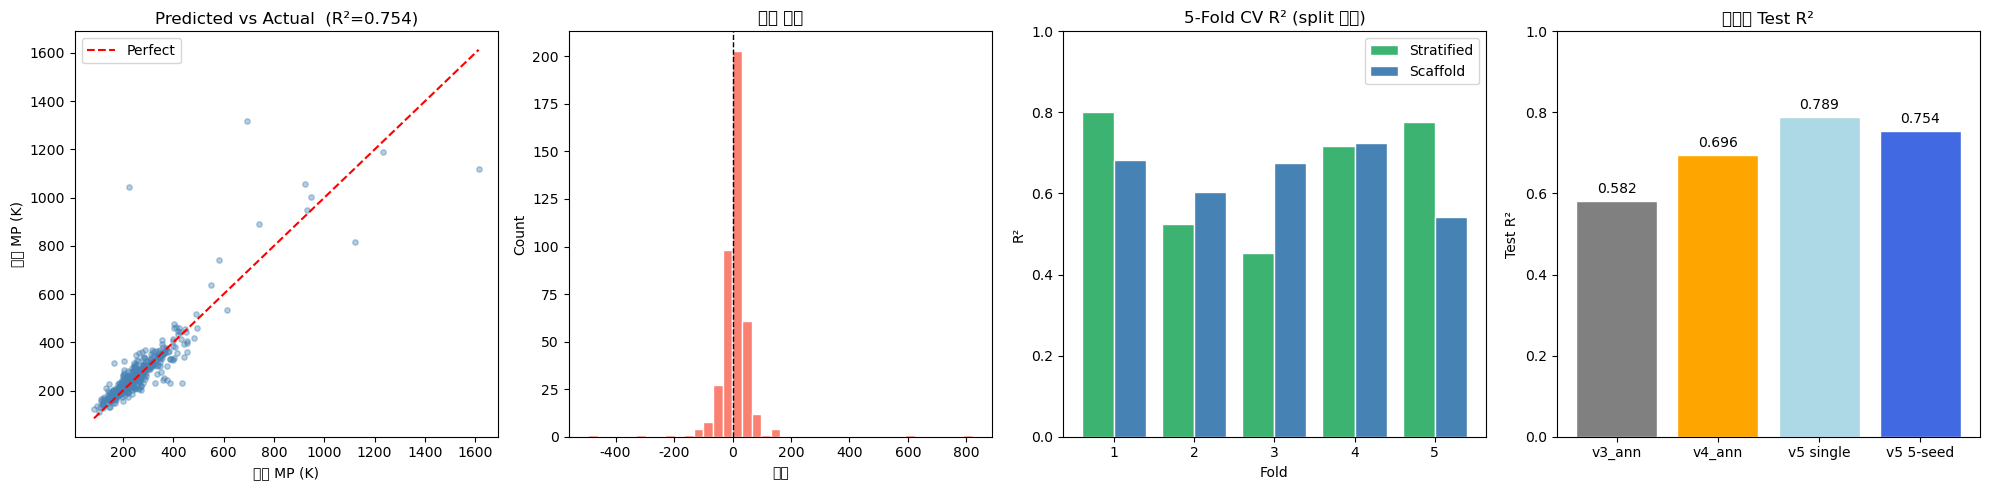

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.4, s=15, color="steelblue")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect")
ax.set_xlabel("실제 MP (K)"); ax.set_ylabel("예측 MP (K)")
ax.set_title(f"Predicted vs Actual  (R²={test_r2:.3f})")
ax.legend()

ax = axes[1]
residuals = y_pred - y_test
ax.hist(residuals, bins=40, color="salmon", edgecolor="white")
ax.axvline(0, color="k", linestyle="--", linewidth=1)
ax.set_xlabel("잔차"); ax.set_ylabel("Count"); ax.set_title("잔차 분포")

ax = axes[2]
x_pos = np.arange(1, 6)
w = 0.4
ax.bar(x_pos - w/2, strat_r2, w, label="Stratified", color="mediumseagreen", edgecolor="white")
ax.bar(x_pos + w/2, scaf_r2,  w, label="Scaffold",   color="steelblue",   edgecolor="white")
ax.set_xlabel("Fold"); ax.set_ylabel("R²")
ax.set_title("5-Fold CV R² (split 비교)")
ax.set_ylim(0, 1); ax.legend()

ax = axes[3]
labels = ["v3_ann", "v4_ann", "v5 single", "v5 5-seed"]
vals   = [0.5821, 0.6958, single_r2, test_r2]
colors = ["gray", "orange", "lightblue", "royalblue"]
ax.bar(labels, vals, color=colors, edgecolor="white")
ax.set_ylabel("Test R²")
ax.set_title("버전별 Test R²")
ax.set_ylim(0, 1)
for i, v in enumerate(vals):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

## 12. 결과 요약 — v3/v4/v5 비교

In [14]:
summary = pd.DataFrame({
    "버전": [
        "base (XGBoost)", "v3_ann (MLP)", "v4_ann (5-step round 1)",
        "v5_ann Stratified CV", "v5_ann Scaffold CV",
        "v5_ann single-seed Test", "v5_ann 5-seed Ensemble Test"
    ],
    "R²": [
        "0.4831", "0.5821", "0.6958",
        f"{np.mean(strat_r2):.4f}", f"{np.mean(scaf_r2):.4f}",
        f"{single_r2:.4f}", f"{test_r2:.4f}"
    ],
    "편차/MAE": [
        "MAE 53.06", "MAE 46.35", "MAE 32.53",
        f"±{np.std(strat_r2):.3f}", f"±{np.std(scaf_r2):.3f}",
        f"MAE {single_mae:.2f}", f"MAE {test_mae:.2f}"
    ],
})
print("=== 버전별 비교 ===")
print(f"노트북 전체 소요: {(time.time()-T0)/60:.1f}분")
summary

=== 버전별 비교 ===
노트북 전체 소요: 1.1분


,버전,R²,편차/MAE
0,base (XGBoost),0.4831,MAE 53.06
1,v3_ann (MLP),0.5821,MAE 46.35
2,v4_ann (5-step round 1),0.6958,MAE 32.53
3,v5_ann Stratified CV,0.6543,±0.140
4,v5_ann Scaffold CV,0.6458,±0.065
5,v5_ann single-seed Test,0.7895,MAE 36.00
6,v5_ann 5-seed Ensemble Test,0.7536,MAE 32.00
